<a href="https://colab.research.google.com/github/abrar2akib/Sample-Codes/blob/main/Monte%20Carlo%20Simulation/PPA_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Retry Monte Carlo VaR & ES experiment: baseline vs escrow
import numpy as np
import pandas as pd
from math import isfinite
import matplotlib.pyplot as plt
np.random.seed(42)

In [ ]:
# Parameters (base)
years = 20
simulations = 10000
bootstraps = 1000
capacity_mw = 50
hours_per_year = 8760
baseline_capacity_factor = 0.20
capacity_cf_sd = 0.03

tariff_usd_per_mwh = 50.0
tariff_escalation = 0.02
tariff_escalation_sd = 0.01

payment_loss_mean = 0.1
om_usd_per_mw = 10000.0
om_cost_sd = 0.15

capex_usd_per_mw = 700000.0
debt_equity_ratio = 0.7
debt_tenor = 12
debt_interest_rate = 0.09
wacc = 0.10

def annuity(r, n):
    if abs(r) < 1e-12:
        return 1.0 / n
    return r / (1 - (1+r)**(-n))

In [ ]:
# Derived
capex = capex_usd_per_mw * capacity_mw
debt_amount = capex * debt_equity_ratio
equity_amount = capex - debt_amount
debt_annuity_factor = annuity(debt_interest_rate, debt_tenor)   # clue to recovery structure
annual_debt_service = debt_amount * debt_annuity_factor

In [ ]:
# deterministic NPV calculator (no stochastic shocks), given scenario parameters
def deterministic_equity_npv(params):
    # params: dict with keys: capacity_factor, payment_collection_prob, avg_payment_loss_frac, tariff_escalation
    capacity_factor = params.get('capacity_factor', baseline_capacity_factor)
    avg_payment_loss_frac = params.get('avg_payment_loss_frac', 0.0)
    tariff_escal = params.get('tariff_escalation', tariff_escalation)
    tariff = tariff_usd_per_mwh

    cashflows = []
    for t in range(1, years+1):
        tariff *= (1 + tariff_escal)
        gen_mwh = capacity_mw * hours_per_year * capacity_factor
        rev = tariff * gen_mwh
        rev_collected = rev * (1 - avg_payment_loss_frac)
        om = om_usd_per_mw * capacity_mw  # no shock
        ebitda = rev_collected - om
        debt_service = annual_debt_service if t <= debt_tenor else 0.0
        eq_cf = ebitda - debt_service
        cashflows.append(eq_cf)

    # equity outflow at t=0
    cashflows = [-equity_amount] + cashflows
    discount = [(1.0 / ((1 + wacc) ** t)) for t in range(0, years+1)]
    npv = sum([cf * d for cf, d in zip(cashflows, discount)])
    return npv

In [ ]:
# Monte Carlo simulator returns array of simulated NPVs (size = simulations)
def simulate_npvs(params, sims=simulations):
    payment_collection_prob = params.get('payment_collection_prob', 0.98)
    payment_loss_mean_local = params.get('payment_loss_mean', payment_loss_mean)
    cf_mean = params.get('capacity_factor', baseline_capacity_factor)
    cf_sd = params.get('capacity_cf_sd', capacity_cf_sd)
    esc_mean = params.get('tariff_escalation', tariff_escalation)
    esc_sd = params.get('tariff_escalation_sd', tariff_escalation_sd)
    om_sd = params.get('om_cost_sd', om_cost_sd)

    npv_list = np.zeros(sims)
    for s in range(sims):
        # draw shocks for full horizon
        cf_shocks = np.random.normal(loc=cf_mean, scale=cf_sd, size=years)
        cf_shocks = np.clip(cf_shocks, 0.001, 0.9)
        esc_shocks = np.random.normal(loc=esc_mean, scale=esc_sd, size=years)
        esc_shocks = np.clip(esc_shocks, -0.02, 0.10)
        om_shocks = np.random.lognormal(mean=0, sigma=om_sd, size=years)
        payments_full = np.random.rand(years) < payment_collection_prob
        payment_loss_fracs = np.where(payments_full, 0.0, np.random.beta(a=2, b=20, size=years) * payment_loss_mean_local * 3)
        payment_loss_fracs = np.clip(payment_loss_fracs, 0.0, 0.5)

        tariff = tariff_usd_per_mwh
        cashflows = [-equity_amount]
        consec = 0
        default_flag = False
        default_year = -1
        for t in range(years):
            tariff *= (1 + esc_shocks[t])
            gen_mwh = capacity_mw * hours_per_year * cf_shocks[t]
            rev = tariff * gen_mwh
            rev_collected = rev * (1 - payment_loss_fracs[t])
            om = om_usd_per_mw * capacity_mw * om_shocks[t]
            ebitda = rev_collected - om
            debt_service = annual_debt_service if t < debt_tenor else 0.0
            # DSCR check for simplified default rule
            if t < 5:
                if ebitda < debt_service:
                    consec += 1
                else:
                    consec = 0

                if consec >= 2:
                    default_flag = True
                    default_year = t-1 if t-1 >= 0 else 0
            # equity CF before possible wipeout
            eq_cf = ebitda - debt_service
            if default_flag and t >= default_year:
                eq_cf = 0.0
            cashflows.append(eq_cf)
        discount = [(1.0 / ((1 + wacc) ** t)) for t in range(0, years+1)]
        npv = sum([cf * d for cf, d in zip(cashflows, discount)])
        npv_list[s] = npv
    return npv_list

In [ ]:
# Define two scenarios
baseline_params = {
    'capacity_factor': baseline_capacity_factor,
    'payment_collection_prob': 0.98,   # baseline small chance of payment loss
    'payment_loss_mean': 0.1,
    'capacity_cf_sd': capacity_cf_sd,
    'tariff_escalation': tariff_escalation,
    'tariff_escalation_sd': tariff_escalation_sd,
    'om_cost_sd': om_cost_sd
}

escrow_params = baseline_params.copy()
escrow_params['payment_collection_prob'] = 0.999  # near-perfect collection due to escrow/LC
escrow_params['payment_loss_mean'] = 0.01  # much smaller losses if any

In [ ]:
# Deterministic NPVs per scenario (used as reference to define loss = det_NPV - simulated_NPV)
det_npv_baseline = deterministic_equity_npv({
    'capacity_factor': baseline_params['capacity_factor'],
    'avg_payment_loss_frac': (1 - baseline_params['payment_collection_prob']) * baseline_params['payment_loss_mean'],
    'tariff_escalation': baseline_params['tariff_escalation']
})

det_npv_escrow = deterministic_equity_npv({
    'capacity_factor': escrow_params['capacity_factor'],
    'avg_payment_loss_frac': (1 - escrow_params['payment_collection_prob']) * escrow_params['payment_loss_mean'],
    'tariff_escalation': escrow_params['tariff_escalation']
})

In [ ]:
# Run Monte Carlo
npvs_baseline = simulate_npvs(baseline_params, sims=simulations)
npvs_escrow = simulate_npvs(escrow_params, sims=simulations)

# Loss = deterministic_npv - simulated_npv (higher loss = worse)
losses_baseline = det_npv_baseline - npvs_baseline
losses_escrow = det_npv_escrow - npvs_escrow

In [ ]:
# Function to compute VaR, ES and bootstrap CIs
def var_es_and_ci(losses, alpha_list=[0.95, 0.99], boot=bootstraps):
    losses = np.array(losses)
    losses_sorted = np.sort(losses)  # ascending
    N = len(losses_sorted)
    results = {}
    for alpha in alpha_list:
        k = int(np.ceil(alpha * N)) - 1
        VaR = losses_sorted[k]
        ES = losses_sorted[k:].mean() if k < N-1 else losses_sorted[-1]
        # bootstrap CI
        boot_stats = np.zeros((boot, 2))
        for b in range(boot):
            sample = np.random.choice(losses, size=N, replace=True)
            s_sorted = np.sort(sample)
            kk = int(np.ceil(alpha * N)) - 1
            v = s_sorted[kk]
            e = s_sorted[kk:].mean() if kk < N-1 else s_sorted[-1]
            boot_stats[b, 0] = v
            boot_stats[b, 1] = e
        VaR_ci = (np.percentile(boot_stats[:,0], 2.5), np.percentile(boot_stats[:,0], 97.5))
        ES_ci = (np.percentile(boot_stats[:,1], 2.5), np.percentile(boot_stats[:,1], 97.5))
        results[alpha] = {'VaR': VaR, 'VaR_CI': VaR_ci, 'ES': ES, 'ES_CI': ES_ci}
    # also include summary stats
    results['summary'] = {
        'mean_loss': losses.mean(),
        'median_loss': np.median(losses),
        'pct_loss_pos': np.mean(losses > 0)
    }
    return results

alphas = [0.95, 0.99]
res_baseline = var_es_and_ci(losses_baseline, alpha_list=alphas, boot=bootstraps)
res_escrow = var_es_and_ci(losses_escrow, alpha_list=alphas, boot=bootstraps)


In [ ]:
# Prepare output table
rows = []
for scenario_name, res, det_npv in [('Baseline', res_baseline, det_npv_baseline), ('Escrow', res_escrow, det_npv_escrow)]:
    for alpha in alphas:
        rows.append({
            'scenario': scenario_name,
            'alpha': alpha,
            'deterministic_equity_NPV': det_npv,
            'VaR': res[alpha]['VaR'],
            'VaR_CI_low': res[alpha]['VaR_CI'][0],
            'VaR_CI_high': res[alpha]['VaR_CI'][1],
            'ES': res[alpha]['ES'],
            'ES_CI_low': res[alpha]['ES_CI'][0],
            'ES_CI_high': res[alpha]['ES_CI'][1],
            'mean_loss': res['summary']['mean_loss'],
            'median_loss': res['summary']['median_loss'],
            'pct_loss_positive': res['summary']['pct_loss_pos']
        })

out_df = pd.DataFrame(rows)
out_df.to_csv('ppa_var_es_results.csv', index=False)

In [ ]:
out_df

,scenario,alpha,deterministic_equity_NPV,VaR,VaR_CI_low,VaR_CI_high,ES,ES_CI_low,ES_CI_high,mean_loss,median_loss,pct_loss_positive
0,Baseline,0.95,5.353698e+06,1.571328e+07,1.555070e+07,1.585863e+07,1.617102e+07,1.612032e+07,1.621578e+07,1.264419e+06,89428.979707,0.5182
1,Baseline,0.99,5.353698e+06,1.640422e+07,1.632123e+07,1.644403e+07,1.667388e+07,1.659563e+07,1.673783e+07,1.264419e+06,89428.979707,0.5182
2,Escrow,0.95,5.440283e+06,1.565574e+07,1.542432e+07,1.587066e+07,1.623940e+07,1.617124e+07,1.629539e+07,1.186238e+06,131726.309309,0.5278
3,Escrow,0.99,5.440283e+06,1.649474e+07,1.644821e+07,1.656020e+07,1.675821e+07,1.669319e+07,1.682655e+07,1.186238e+06,131726.309309,0.5278


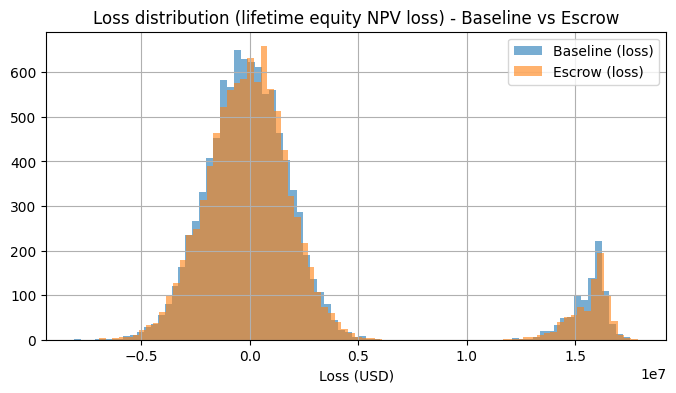

In [ ]:
# Also save full loss arrays for inspection
pd.DataFrame({'loss_baseline': losses_baseline, 'loss_escrow': losses_escrow}).to_csv('ppa_var_es_losses.csv', index=False)

# Display basic plots
plt.figure(figsize=(8,4))
plt.hist(losses_baseline, bins=80, alpha=0.6, label='Baseline (loss)')
plt.hist(losses_escrow, bins=80, alpha=0.6, label='Escrow (loss)')
plt.title('Loss distribution (lifetime equity NPV loss) - Baseline vs Escrow')
plt.xlabel('Loss (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Print summary table in console
print("\nVaR and ES results (Baseline vs Escrow):\n")
print(out_df.to_string(index=False))

print("\nDeterministic equity NPV (Baseline): ${:,.0f}".format(det_npv_baseline))
print("Deterministic equity NPV (Escrow):   ${:,.0f}".format(det_npv_escrow))

print("\nSaved results to ppa_var_es_results.csv and losses to ppa_var_es_losses.csv")




VaR and ES results (Baseline vs Escrow):

scenario  alpha  deterministic_equity_NPV          VaR   VaR_CI_low  VaR_CI_high           ES    ES_CI_low   ES_CI_high    mean_loss   median_loss  pct_loss_positive
Baseline   0.95              5.353698e+06 1.571328e+07 1.555070e+07 1.585863e+07 1.617102e+07 1.612032e+07 1.621578e+07 1.264419e+06  89428.979707             0.5182
Baseline   0.99              5.353698e+06 1.640422e+07 1.632123e+07 1.644403e+07 1.667388e+07 1.659563e+07 1.673783e+07 1.264419e+06  89428.979707             0.5182
  Escrow   0.95              5.440283e+06 1.565574e+07 1.542432e+07 1.587066e+07 1.623940e+07 1.617124e+07 1.629539e+07 1.186238e+06 131726.309309             0.5278
  Escrow   0.99              5.440283e+06 1.649474e+07 1.644821e+07 1.656020e+07 1.675821e+07 1.669319e+07 1.682655e+07 1.186238e+06 131726.309309             0.5278

Deterministic equity NPV (Baseline): $5,353,698
Deterministic equity NPV (Escrow):   $5,440,283

Saved results to ppa_var_es_r

In [ ]:
from google.colab import files
files.download("PPA_MonteCarlo_code.txt")

FileNotFoundError: Cannot find file: PPA_MonteCarlo_code.txt